In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector


In [51]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",      
    database="retail_sales"
)

print("Connected Successfully!")

Connected Successfully!


In [52]:
customers = pd.read_sql("SELECT * FROM customers", conn)
orders = pd.read_sql("SELECT * FROM orders", conn)
order_items = pd.read_sql("SELECT * FROM order_items", conn)
products = pd.read_sql("SELECT * FROM products", conn)
payments = pd.read_sql("SELECT * FROM payments", conn)
reviews = pd.read_sql("SELECT * FROM reviews", conn)

print("All tables loaded successfully!")

C:\Users\kiran\AppData\Local\Temp\ipykernel_10744\3945673429.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM customers", conn)
C:\Users\kiran\AppData\Local\Temp\ipykernel_10744\3945673429.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("SELECT * FROM orders", conn)
C:\Users\kiran\AppData\Local\Temp\ipykernel_10744\3945673429.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("SELECT * FROM order_items", conn)
C:\Users\kiran\AppDat

All tables loaded successfully!


In [53]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)


In [54]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00012a2ce6f8dcda20d059ce98491703,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,000161a058600d5901f007fab4c27140,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,0001fd6190edaaf884bcaf3d49edf079,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES
3,0002414f95344307404f0ace7a26f1d5,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG
4,000379cdec625522490c315e70c7a9fb,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP


In [55]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17


In [56]:
order_items.head()

,order_id,order_item,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [57]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00066f42aeeb9f3007548bb9d3f33c38,perfumaria,53.0,596.0,6.0,300.0,20.0,16.0,16.0
1,00088930e925c41fd95ebfe695fd2655,automotivo,56.0,752.0,4.0,1225.0,55.0,10.0,26.0
2,0009406fd7479715e4bef61dd91f2462,cama_mesa_banho,50.0,266.0,2.0,300.0,45.0,15.0,35.0
3,000b8f95fcb9e0096488278317764d19,utilidades_domesticas,25.0,364.0,3.0,550.0,19.0,24.0,12.0
4,000d9be29b5207b54e86aa1b1ac54872,relogios_presentes,48.0,613.0,4.0,250.0,22.0,11.0,15.0


In [58]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,1,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,3,218.04


In [59]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,None,None,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,None,None,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,None,None,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,None,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,None,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


In [60]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [61]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [62]:
orders_customers = pd.merge(
    orders,
    customers,
    on="customer_id",
    how="inner"
)

orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP


In [63]:
orders_customers.shape

(99441, 12)

In [64]:
sales = pd.merge(
    orders_customers,
    order_items,
    on="order_id",
    how="inner"
)

sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [65]:
sales.shape

(112650, 18)

In [66]:
sales = pd.merge(
    sales,
    products,
    on="product_id",
    how="left"
)

sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,...,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,...,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,...,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,...,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,...,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [67]:
sales = pd.merge(
    sales,
    payments,
    on="order_id",
    how="left"
)

sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,...,598.0,4.0,650.0,28.0,9.0,14.0,1.0,credit_card,2.0,72.19
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,...,239.0,2.0,30000.0,50.0,30.0,40.0,1.0,credit_card,3.0,259.83
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,...,695.0,2.0,3050.0,33.0,13.0,33.0,1.0,credit_card,5.0,216.87
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,...,480.0,1.0,200.0,16.0,10.0,15.0,1.0,credit_card,2.0,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,...,409.0,1.0,3750.0,35.0,40.0,30.0,1.0,credit_card,3.0,218.04


In [68]:
sales = pd.merge(
    sales,
    reviews,
    on="order_id",
    how="left"
)

sales.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,871766c5855e863f6eccc05f988b23cb,28013,...,1.0,credit_card,2.0,72.19,97ca439bc427b48bc1cd7177abe71365,5.0,None,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,eb28e67c4c0b83846050ddfb8a35d051,15775,...,1.0,credit_card,3.0,259.83,7b07bacd811c4117b742569b04ce3580,4.0,None,None,2017-05-13,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,3818d81c6709e39d06b2738a8d3a2474,35661,...,1.0,credit_card,5.0,216.87,0c5b33dea94867d1ac402749e5438e8b,5.0,None,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,af861d436cfc08b2c2ddefd0ba074622,12952,...,1.0,credit_card,2.0,25.78,f4028d019cb58564807486a6aaf33817,4.0,None,None,2018-08-15,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,64b576fb70d441e8f1b2d7d446e483c5,13226,...,1.0,credit_card,3.0,218.04,940144190dcba6351888cafa43f3a3a5,5.0,None,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59


In [69]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118310 entries, 0 to 118309
Data columns (total 36 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118310 non-null  object        
 1   customer_id                    118310 non-null  object        
 2   order_status                   118310 non-null  object        
 3   order_purchase_timestamp       118310 non-null  datetime64[ns]
 4   order_approved_at              118295 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117056 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118310 non-null  datetime64[ns]
 8   customer_unique_id             118310 non-null  object        
 9   customer_zip_code_prefix       118310 non-null  int64         
 10  customer_city                  118310 non-null  object        
 11  

In [70]:
sales.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [71]:
sales.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_zip_code_prefix,order_item,shipping_limit_date,price,freight_value,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_installments,payment_value,review_score,review_creation_date,review_answer_timestamp
count,118310,118295,117056,115722,118310,118310.000000,118310.000000,118310,118310.000000,118310.000000,...,118290.000000,118290.000000,118290.000000,118290.000000,118307.000000,118307.000000,118307.000000,117332.000000,117332,117332
mean,2017-12-30 06:31:38.646944768,2017-12-30 17:59:37.706318848,2018-01-03 08:29:45.624487424,2018-01-12 20:55:38.199616768,2018-01-23 03:21:29.865607168,35050.658693,1.196543,2018-01-05 22:06:13.308807680,120.646603,20.032387,...,2112.250740,30.265145,16.619706,23.074799,1.094069,2.943317,172.575102,4.031390,2018-01-11 23:40:04.868237568,2018-01-15 03:11:39.873777152
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1003.000000,1.000000,2016-09-19 00:15:34,0.850000,0.000000,...,0.000000,7.000000,2.000000,6.000000,1.000000,0.000000,0.000000,1.000000,2016-10-06 00:00:00,2016-10-07 18:32:28
25%,2017-09-11 15:08:33.750000128,2017-09-12 04:24:02,2017-09-14 19:52:14.249999872,2017-09-22 21:54:31.249999872,2017-10-02 00:00:00,11310.000000,1.000000,2017-09-18 14:30:33,39.900000,13.080000,...,300.000000,18.000000,8.000000,15.000000,1.000000,1.000000,60.850000,4.000000,2017-09-22 00:00:00,2017-09-25 23:24:55
50%,2018-01-17 22:38:25.500000,2018-01-18 10:17:08,2018-01-23 17:04:54,2018-02-01 03:17:55,2018-02-14 00:00:00,24275.500000,1.000000,2018-01-25 04:11:15.500000,74.900000,16.280000,...,700.000000,25.000000,13.000000,20.000000,1.000000,2.000000,108.200000,5.000000,2018-02-01 00:00:00,2018-02-03 23:04:20
75%,2018-05-03 16:34:57,2018-05-03 23:55:08,2018-05-07 14:57:00,2018-05-15 00:08:31.500000,2018-05-25 00:00:00,58636.250000,1.000000,2018-05-10 02:51:40.249999872,134.900000,21.180000,...,1800.000000,38.000000,20.000000,30.000000,1.000000,4.000000,189.260000,5.000000,2018-05-15 00:00:00,2018-05-17 15:58:57.249999872
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,99990.000000,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,...,40425.000000,105.000000,105.000000,118.000000,29.000000,24.000000,13664.080000,5.000000,2018-08-31 00:00:00,2018-10-29 12:27:35
std,NaN,NaN,NaN,NaN,NaN,29824.585904,0.699489,NaN,184.109691,15.836850,...,3786.695111,16.189367,13.453584,11.749139,0.728579,2.777877,267.110727,1.387994,NaN,NaN


In [72]:
sales.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1254
order_delivered_customer_date      2588
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item                            0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
product_category_name              1709
product_name_lenght                1709
product_description_lenght         1709
product_photos_qty                 1709
product_weight_g                     20
product_length_cm                    20
product_height_cm                    20


In [73]:
sales[['order_purchase_timestamp']].dtypes

order_purchase_timestamp    datetime64[ns]
dtype: object

In [74]:
sales['order_purchase_timestamp'] = pd.to_datetime(
    sales['order_purchase_timestamp']
)

In [75]:
sales['order_delivered_customer_date'] = pd.to_datetime(
    sales['order_delivered_customer_date']
)

In [76]:
sales['order_estimated_delivery_date'] = pd.to_datetime(
    sales['order_estimated_delivery_date']
)

In [77]:
sales['review_creation_date'] = pd.to_datetime(
    sales['review_creation_date']
)

In [78]:
sales['review_answer_timestamp'] = pd.to_datetime(
    sales['review_answer_timestamp']
)

In [79]:
sales['Month'] = sales['order_purchase_timestamp'].dt.to_period('M')

In [80]:
sales['Year'] = sales['order_purchase_timestamp'].dt.year

In [81]:
sales['Month_Name'] = sales['order_purchase_timestamp'].dt.month_name()

In [82]:
monthly_revenue = (
    sales.groupby('Month')['price']
    .sum()
    .reset_index()
)

monthly_revenue

,Month,price
0,2016-09,267.36
1,2016-10,51068.92
2,2016-12,10.90
3,2017-01,129895.32
4,2017-02,262013.86
5,2017-03,398117.44
6,2017-04,392595.36
7,2017-05,549226.84
8,2017-06,456867.47
9,2017-07,536906.96


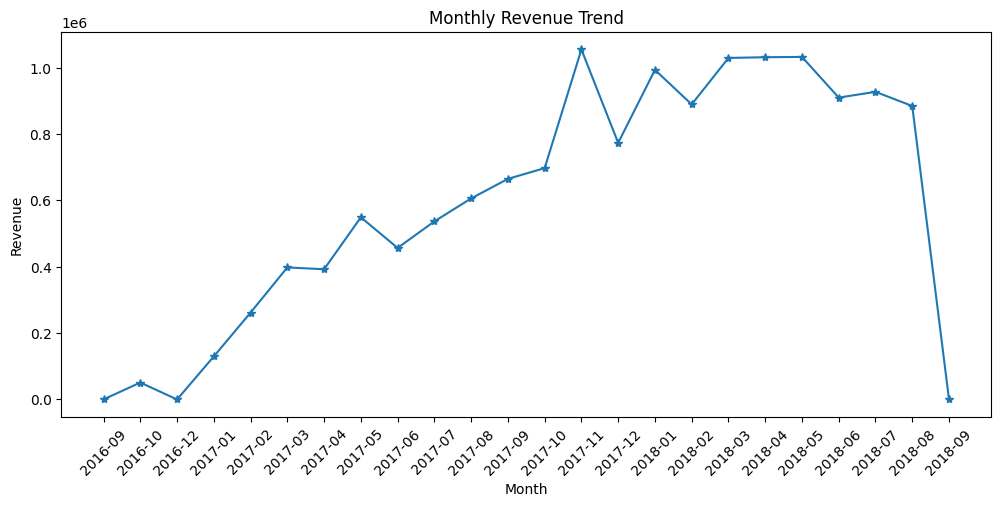

In [83]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue['Month'].astype(str),
    monthly_revenue['price'],
    marker='*'
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

In [84]:
sales.groupby("Month")["order_id"].count().reset_index()

,Month,order_id
0,2016-09,6
1,2016-10,385
2,2016-12,1
3,2017-01,1023
4,2017-02,2073
5,2017-03,3201
6,2017-04,2864
7,2017-05,4445
8,2017-06,3822
9,2017-07,4887


In [85]:
top_categories = (
    sales.groupby("product_category_name")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories

product_category_name
beleza_saude              1301947.97
relogios_presentes        1254322.95
cama_mesa_banho           1107249.09
esporte_lazer             1029603.88
informatica_acessorios     950053.69
moveis_decoracao           772096.17
utilidades_domesticas      668880.94
cool_stuff                 664637.13
automotivo                 618395.50
ferramentas_jardim         519473.33
Name: price, dtype: float64

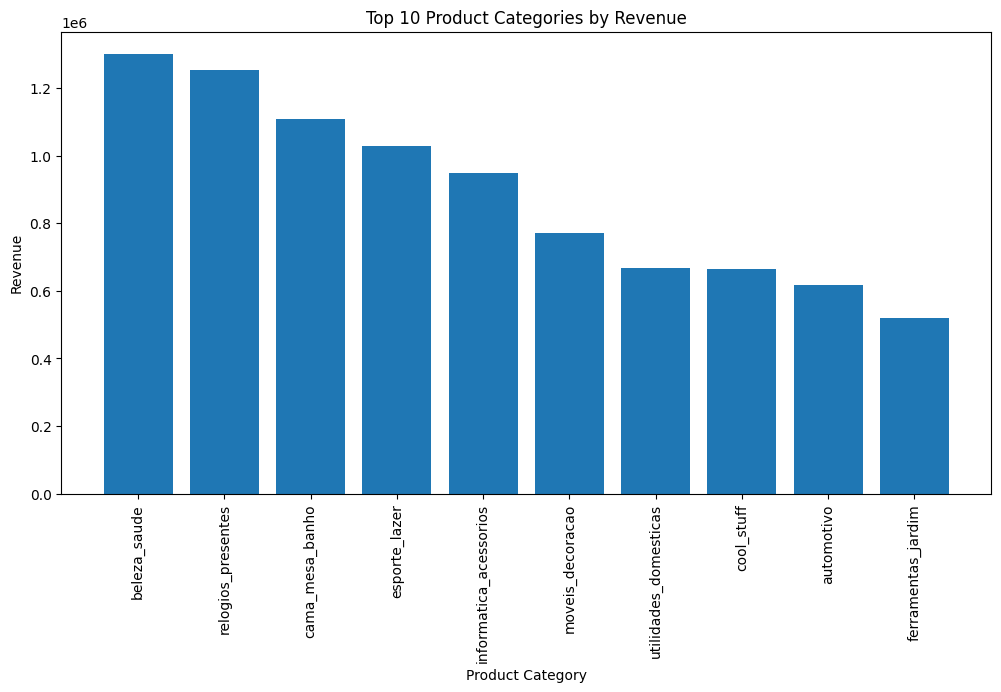

In [86]:
plt.figure(figsize=(12,6))

plt.bar(
    top_categories.index,
    top_categories.values
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

In [87]:
state_revenue=(sales.groupby ("customer_state")["price"].sum().sort_values(ascending=False))
state_revenue
               

customer_state
SP    5477008.74
RJ    1921752.53
MG    1645847.27
RS     791716.84
PR     708794.22
BA     543243.99
SC     539896.20
DF     315122.29
GO     313198.27
ES     284771.30
PE     272271.97
CE     240095.13
PA     184889.93
MT     171109.74
PB     123816.24
MA     123077.67
MS     121358.47
RN      94607.86
PI      92227.70
AL      83314.32
SE      60954.60
TO      56251.91
RO      46964.03
AM      22865.26
AC      17059.44
AP      13654.30
RR       7829.43
Name: price, dtype: float64

In [88]:
print(state_revenue.index)


Index(['SP', 'RJ', 'MG', 'RS', 'PR', 'BA', 'SC', 'DF', 'GO', 'ES', 'PE', 'CE',
       'PA', 'MT', 'PB', 'MA', 'MS', 'RN', 'PI', 'AL', 'SE', 'TO', 'RO', 'AM',
       'AC', 'AP', 'RR'],
      dtype='object', name='customer_state')


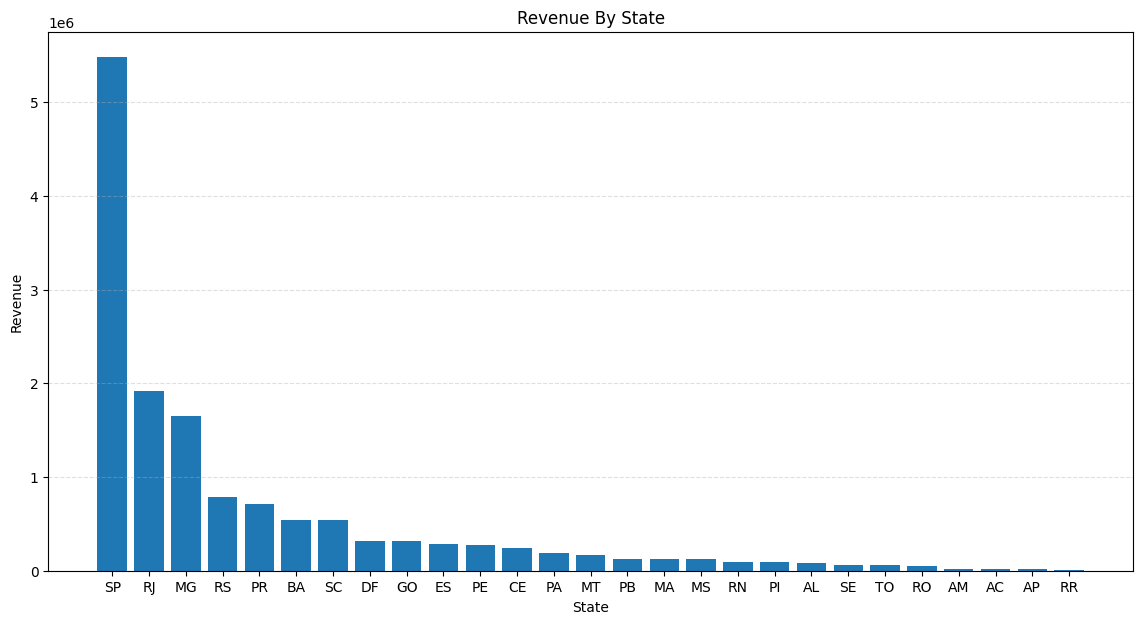

In [89]:
plt.figure(figsize=(14,7))
plt.bar(state_revenue.index,state_revenue.values)
plt.title("Revenue By State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [90]:
customer_spending=(sales.groupby("customer_id")["price"].sum().sort_values(ascending=False).head(10))
customer_spending

customer_id
1617b1357756262bfa56ab541c47bc16    13440.00
9af2372a1e49340278e7c1ef8d749f34    11383.95
de832e8dbb1f588a47013e53feaa67cc    10856.10
63b964e79dee32a3587651701a2b8dbf     9888.00
6f241d5bbb142b6f764387c8c270645a     9520.14
926b6a6fb8b6081e00b335edaf578d35     7998.00
f959b7bc834045511217e6410985963f     7799.40
eb7a157e8da9c488cd4ddc48711f1097     7798.00
ec5b2ba62e574342386871631fafd3fc     7160.00
3118aefef04e5e97d0e339cd75d6d775     6909.00
Name: price, dtype: float64

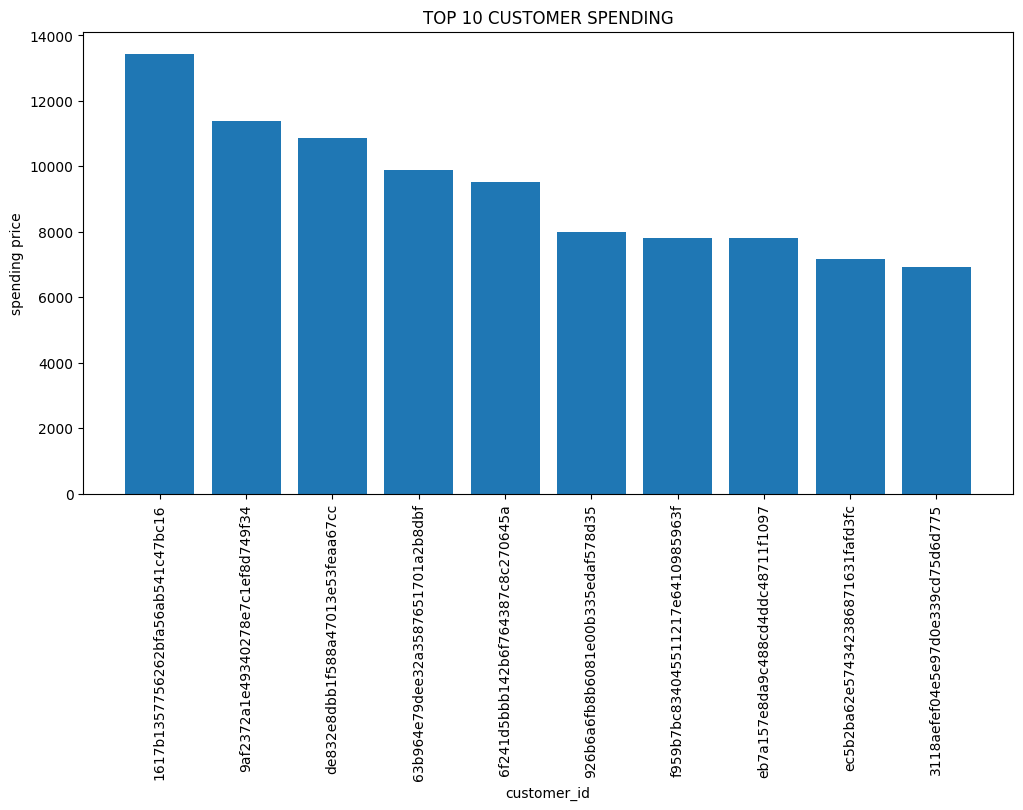

In [91]:
plt.figure(figsize=(12,6))
plt.bar(customer_spending.index,customer_spending.values)
plt.title("TOP 10 CUSTOMER SPENDING")
plt.xlabel("customer_id")
plt.ylabel("spending price")
plt.xticks(rotation=90)
plt.show()

In [92]:
payment_type=(sales.groupby("payment_type")["payment_type"].count().sort_values(ascending=False))
payment_type             

payment_type
credit_card    87258
boleto         23018
voucher         6332
debit_card      1699
Name: payment_type, dtype: int64

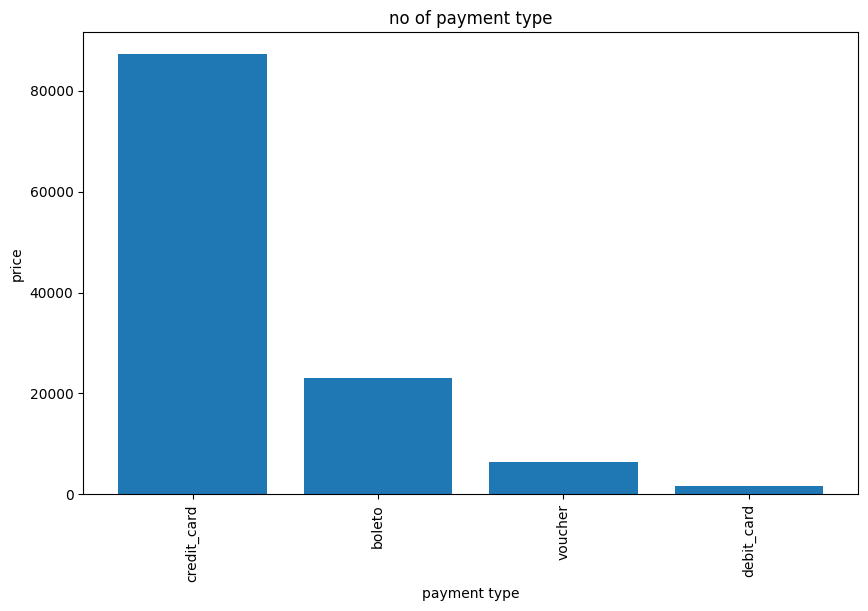

In [93]:
plt.figure(figsize=(10,6))
plt.bar(payment_type.index,payment_type.values)
plt.title("no of payment type")
plt.xlabel("payment type")
plt.xticks(rotation=90)
plt.ylabel("price")
plt.show()

In [94]:
sales.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1254
order_delivered_customer_date      2588
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item                            0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
product_category_name              1709
product_name_lenght                1709
product_description_lenght         1709
product_photos_qty                 1709
product_weight_g                     20
product_length_cm                    20
product_height_cm                    20


In [95]:
reviews_count=sales["review_score"].value_counts().sort_index()
reviews_count

review_score
1.0    14857
2.0     4085
3.0     9840
4.0    22286
5.0    66264
Name: count, dtype: int64

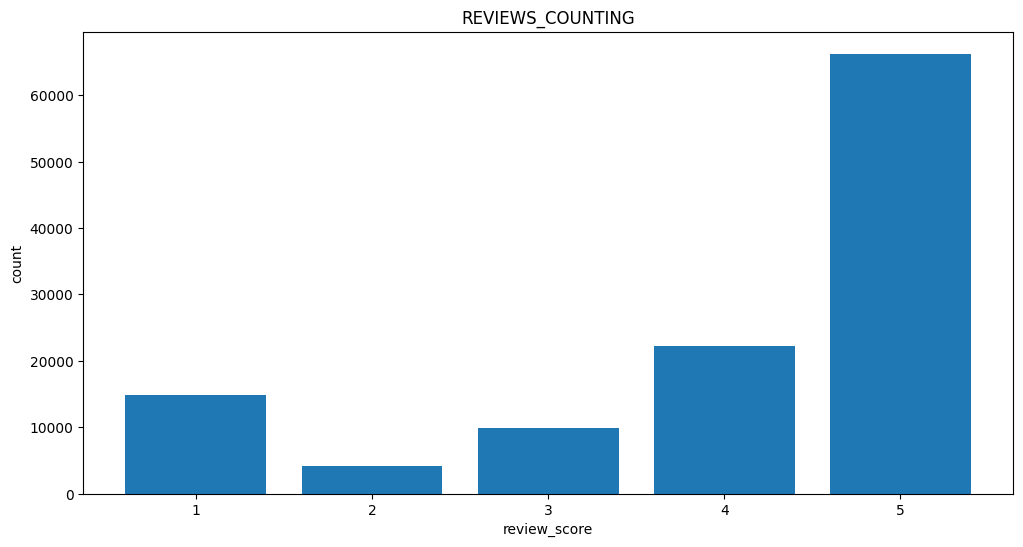

In [96]:
plt.figure(figsize=(12,6))
plt.bar(reviews_count.index,reviews_count.values)
plt.title("REVIEWS_COUNTING")
plt.xlabel("review_score")
plt.ylabel("count")
plt.show()


In [98]:
top_products = (
    sales.groupby("product_id")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

product_id
bb50f2e236e5eea0100680137654686c    68810.00
d6160fb7873f184099d9bc95e30376af    56948.83
6cdd53843498f92890544667809f1595    55779.90
d1c427060a0f73f6b889a5c7c61f2ac4    49141.40
99a4788cb24856965c36a24e339b6058    46575.66
25c38557cf793876c5abdd5931f922db    44829.32
3dd2a17168ec895c781a9191c1e95ad7    41682.20
aca2eb7d00ea1a7b8ebd4e68314663af    38248.20
53b36df67ebb7c41585e8d54d6772e08    38158.21
5f504b3a1c75b73d6151be81eb05bdc9    37733.90
Name: price, dtype: float64

In [99]:
len(top_products)

10

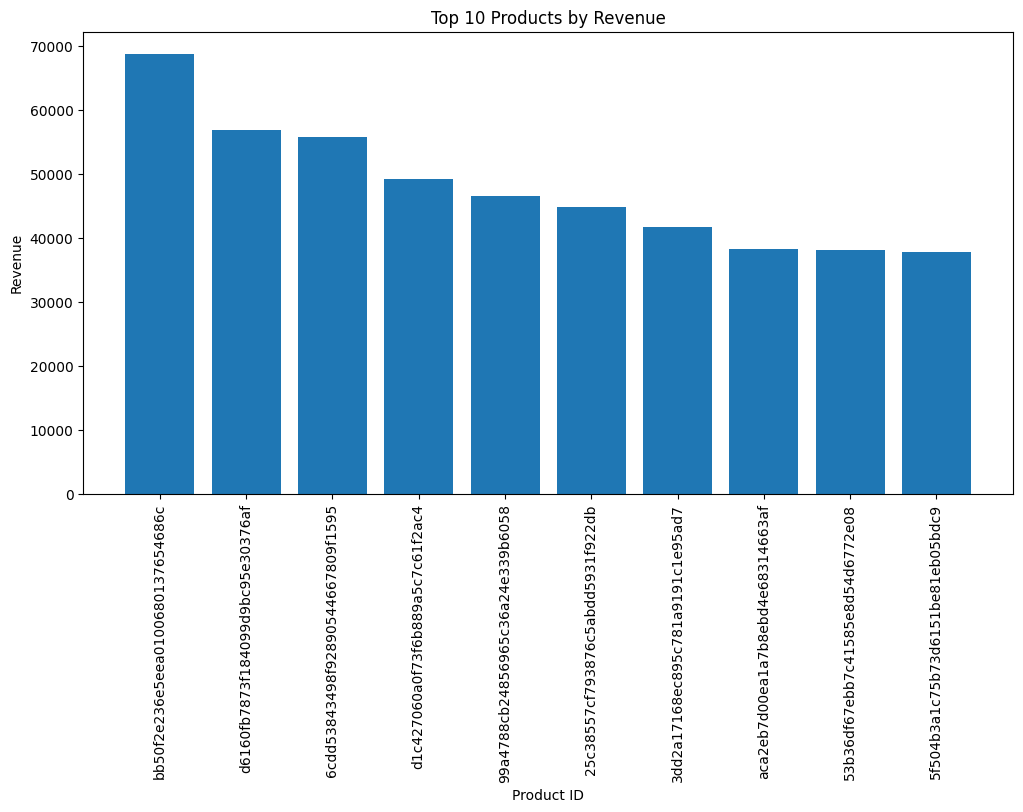

In [100]:
plt.figure(figsize=(12,6))
plt.bar(top_products.index, top_products.values)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product ID")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

In [114]:
monthly_count=(sales.groupby("Month")["order_id"].nunique())
monthly_count

Month
2016-09       3
2016-10     308
2016-12       1
2017-01     789
2017-02    1733
2017-03    2641
2017-04    2391
2017-05    3660
2017-06    3217
2017-07    3969
2017-08    4293
2017-09    4243
2017-10    4568
2017-11    7451
2017-12    5624
2018-01    7220
2018-02    6694
2018-03    7188
2018-04    6934
2018-05    6853
2018-06    6160
2018-07    6273
2018-08    6452
2018-09       1
Freq: M, Name: order_id, dtype: int64

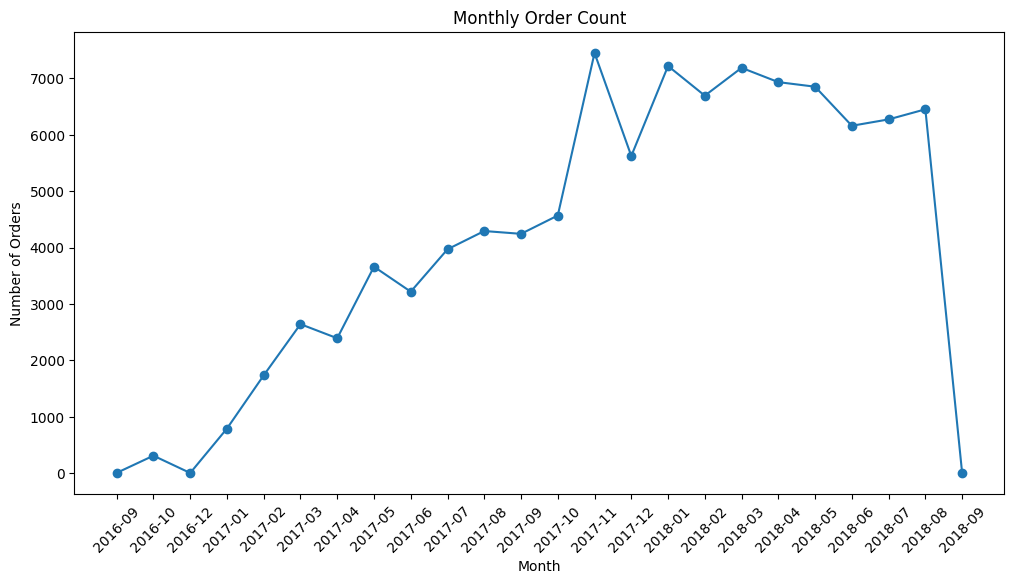

In [115]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_count.index.astype(str),
    monthly_count.values,
    marker="o"
)

plt.title("Monthly Order Count")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

In [116]:
sales["delivery_days"] = (
    sales["order_delivered_customer_date"] -
    sales["order_purchase_timestamp"]
).dt.days

In [117]:
sales["delivery_days"].head()

0     7.0
1    16.0
2     7.0
3     6.0
4    25.0
Name: delivery_days, dtype: float64

In [120]:
average_orders=(round(sales["delivery_days"].mean(),2))
average_orders

np.float64(12.02)

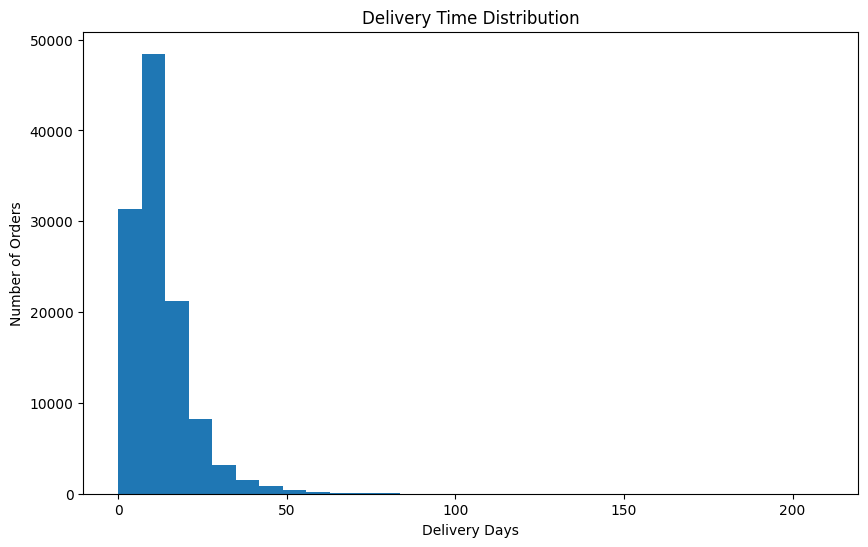

In [122]:
plt.figure(figsize=(10,6))

plt.hist(sales["delivery_days"], bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.show()

In [123]:
sales[["price", "product_weight_g"]].corr()

,price,product_weight_g
price,1.000000,0.339367
product_weight_g,0.339367,1.000000


In [126]:
cities_revenue=(sales.groupby("customer_city")["price"].sum().sort_values(ascending=False).head(10))
cities_revenue.head(10)

customer_city
sao paulo         2020902.59
rio de janeiro    1036314.55
belo horizonte     368768.85
brasilia           314328.80
curitiba           219071.05
salvador           197445.32
campinas           197304.24
porto alegre       196867.42
guarulhos          155465.31
niteroi            133096.16
Name: price, dtype: float64

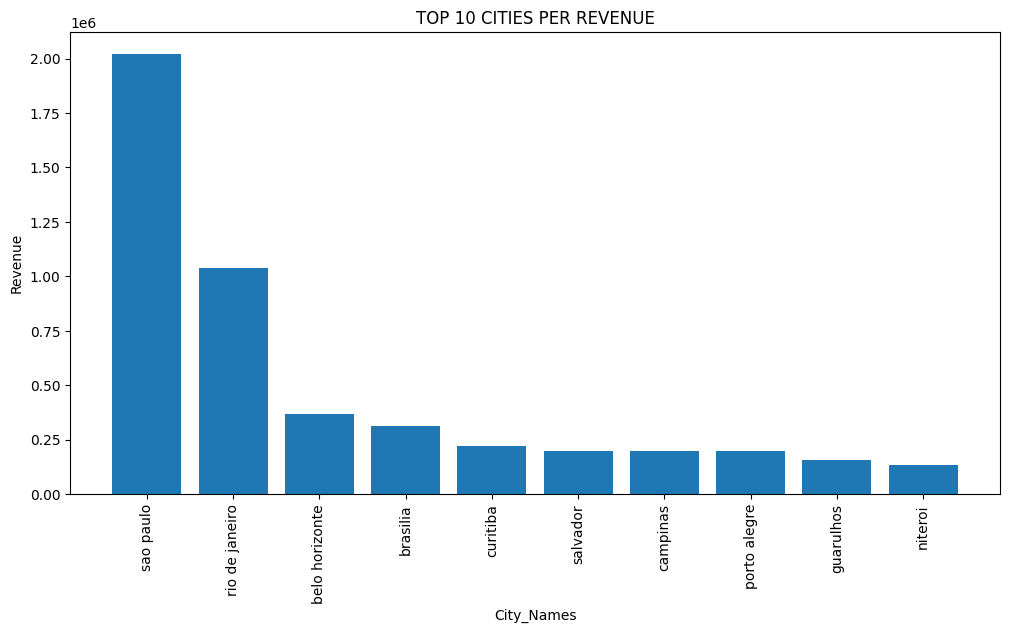

In [127]:
plt.figure(figsize=(12,6))
plt.bar(cities_revenue.index,cities_revenue.values)
plt.title("TOP 10 CITIES PER REVENUE")
plt.xlabel("City_Names")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

In [132]:
average_rating=(sales.groupby("customer_state")["review_score"].mean())
average_rating

customer_state
AC    4.094737
AL    3.718954
AM    4.082353
AP    4.240964
BA    3.819631
CE    3.823301
DF    4.002820
ES    3.985770
GO    3.986755
MA    3.682088
MG    4.086222
MS    4.076112
MT    3.895255
PA    3.795826
PB    4.001590
PE    3.965352
PI    3.852113
PR    4.106226
RJ    3.813206
RN    4.054770
RO    4.035088
RR    3.576923
RS    4.039134
SC    4.003035
SE    3.827848
SP    4.126913
TO    4.142012
Name: review_score, dtype: float64

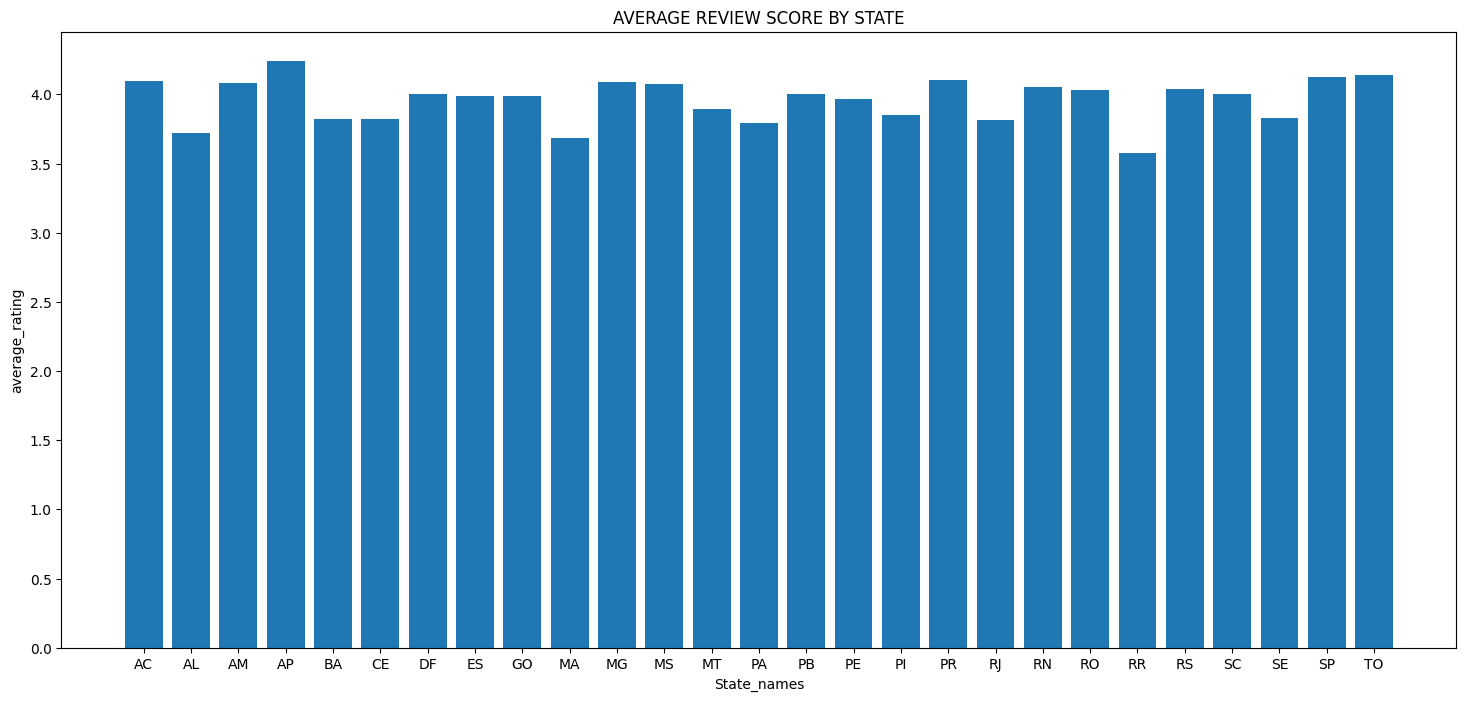

In [137]:
plt.figure(figsize=(18,8))
plt.bar(average_rating.index,average_rating.values)
plt.title("AVERAGE REVIEW SCORE BY STATE")
plt.xlabel("State_names")
plt.ylabel("average_rating")

plt.show()

In [138]:
payment_type=(sales.groupby("payment_type")["price"].sum().sort_values(ascending=False))
payment_type

payment_type
credit_card    11017976.56
boleto          2405984.26
voucher          665249.55
debit_card       184354.31
Name: price, dtype: float64

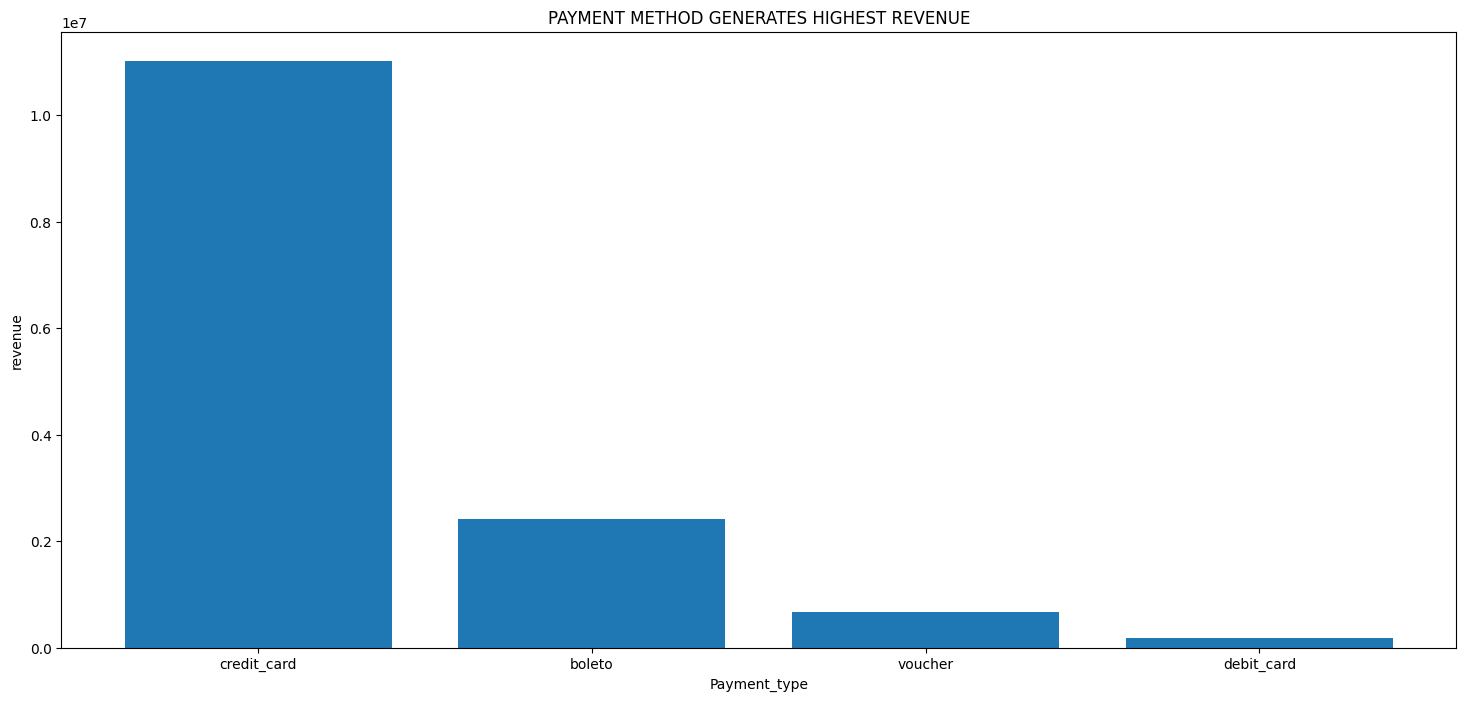

In [139]:

plt.figure(figsize=(18,8))
plt.bar(payment_type.index,payment_type.values)
plt.title("PAYMENT METHOD GENERATES HIGHEST REVENUE")
plt.xlabel("Payment_type")
plt.ylabel("revenue")

plt.show()

In [140]:
sales.to_csv("retail_sales_cleaned.csv", index=False)

print("CSV exported successfully!")

CSV exported successfully!


In [141]:
import os

print(os.getcwd())

C:\Users\kiran\OneDrive\Desktop\Retail_Sales_Project\sql


In [142]:
sales.to_csv(
    r"C:\Users\kiran\OneDrive\Desktop\Retail_Sales_Project\powerbi\retail_sales_cleaned.csv",
    index=False
)

print("CSV exported successfully!")

CSV exported successfully!
